# Experiment Data Visualization

This notebook visualizes the hand and gaze trajectories from the experiment log file.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load the data
log_file_path = "../../../../Assets/Logs/Participant_1_2025-11-23_13-08-33/frame_log.csv"
df = pd.read_csv(log_file_path)

# Display basic info
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 61 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          20058 non-null  float64
 1   TrialID            20058 non-null  int64  
 2   Condition          20058 non-null  object 
 3   Phase              20058 non-null  object 
 4   StartRegionName    20058 non-null  object 
 5   TargetRegionName   20058 non-null  object 
 6   TranslationAxis    20058 non-null  object 
 7   RotationAxis       20058 non-null  object 
 8   RotationAngle      20058 non-null  int64  
 9   HeadPosX           20058 non-null  float64
 10  HeadPosY           20058 non-null  float64
 11  HeadPosZ           20058 non-null  float64
 12  HeadRotX           20058 non-null  float64
 13  HeadRotY           20058 non-null  float64
 14  HeadRotZ           20058 non-null  float64
 15  HeadRotW           20058 non-null  float64
 16  HandPosX           200

,Timestamp,TrialID,Condition,Phase,StartRegionName,TargetRegionName,TranslationAxis,RotationAxis,RotationAngle,HeadPosX,...,TargetObjectPosY,TargetObjectPosZ,TargetObjectRotX,TargetObjectRotY,TargetObjectRotZ,TargetObjectRotW,IsGrabbing,IsIndexPinching,IsInThreshold,IsRetryPressed
0,0.00,1,HH_Inter,PreTrial,Center Middle,Center Far,MinusX,MinusXMinusZ,45,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,False,False,False,False
1,0.02,1,HH_Inter,PreTrial,Center Middle,Center Far,MinusX,MinusXMinusZ,45,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,False,False,False,False
2,0.04,1,HH_Inter,PreTrial,Center Middle,Center Far,MinusX,MinusXMinusZ,45,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,False,False,False,False
3,0.06,1,HH_Inter,PreTrial,Center Middle,Center Far,MinusX,MinusXMinusZ,45,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,False,False,False,False
4,0.08,1,HH_Inter,PreTrial,Center Middle,Center Far,MinusX,MinusXMinusZ,45,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,False,False,False,False


## Trajectory Visualization

We will visualize the 3D trajectories of the Hand and Gaze.

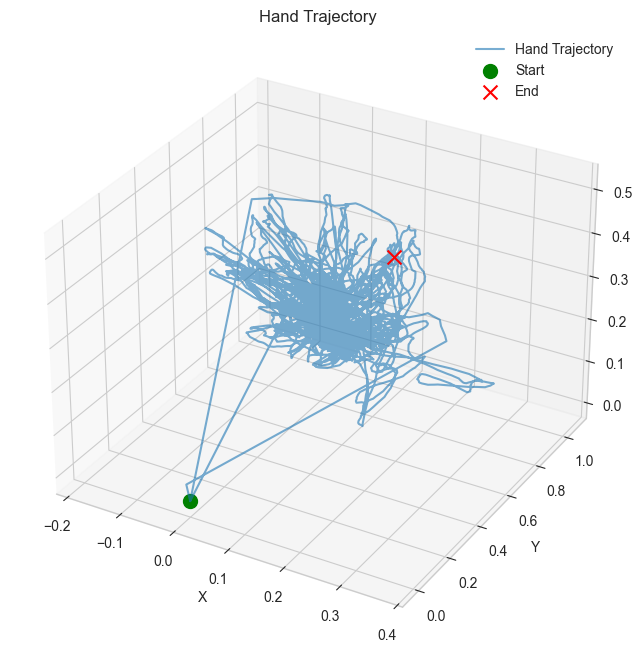

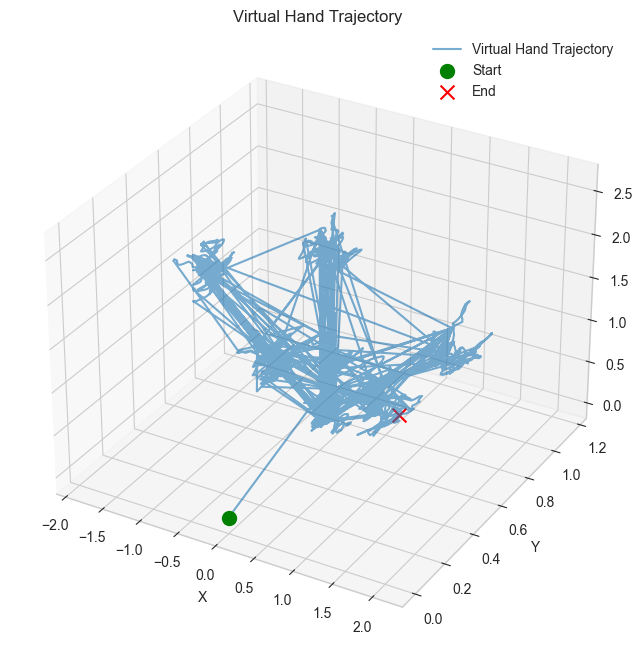

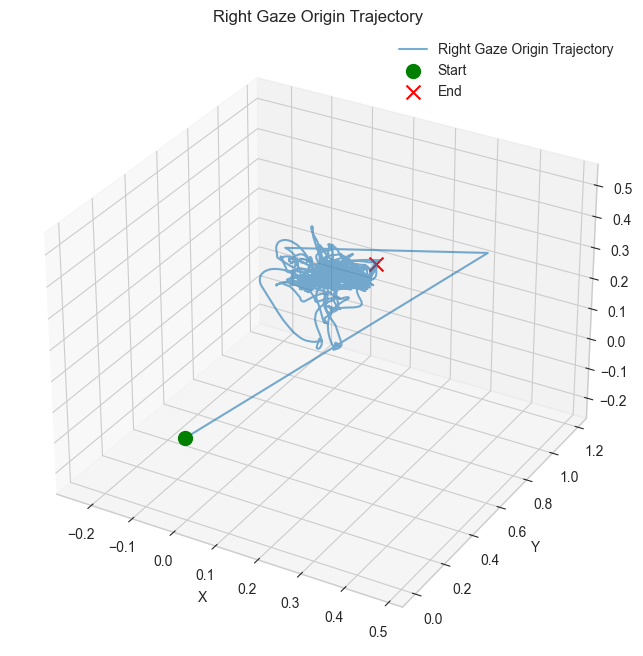

In [3]:
def plot_3d_trajectory(df, x_col, y_col, z_col, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot trajectory
    ax.plot(df[x_col], df[y_col], df[z_col], label=title, alpha=0.6)
    
    # Plot start and end points
    ax.scatter(df[x_col].iloc[0], df[y_col].iloc[0], df[z_col].iloc[0], c='green', marker='o', s=100, label='Start')
    ax.scatter(df[x_col].iloc[-1], df[y_col].iloc[-1], df[z_col].iloc[-1], c='red', marker='x', s=100, label='End')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    ax.legend()
    plt.show()

# Plot Hand Trajectory
plot_3d_trajectory(df, 'HandPosX', 'HandPosY', 'HandPosZ', 'Hand Trajectory')

# Plot Virtual Hand Trajectory
plot_3d_trajectory(df, 'VirtualHandPosX', 'VirtualHandPosY', 'VirtualHandPosZ', 'Virtual Hand Trajectory')

# Plot Gaze Origin (Right Eye)
plot_3d_trajectory(df, 'RightGazeOriginX', 'RightGazeOriginY', 'RightGazeOriginZ', 'Right Gaze Origin Trajectory')

## Time Series Visualization

Check for continuity and tracking quality.

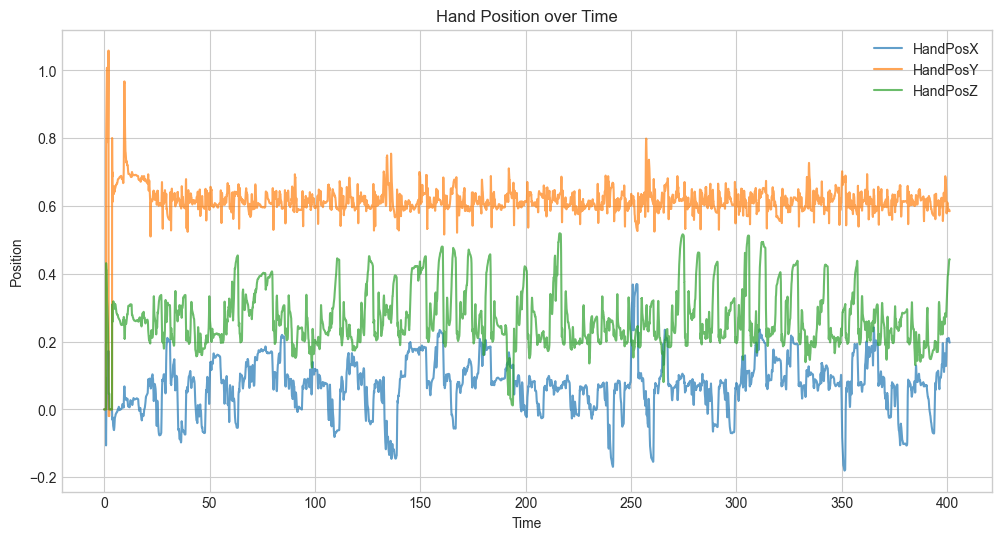

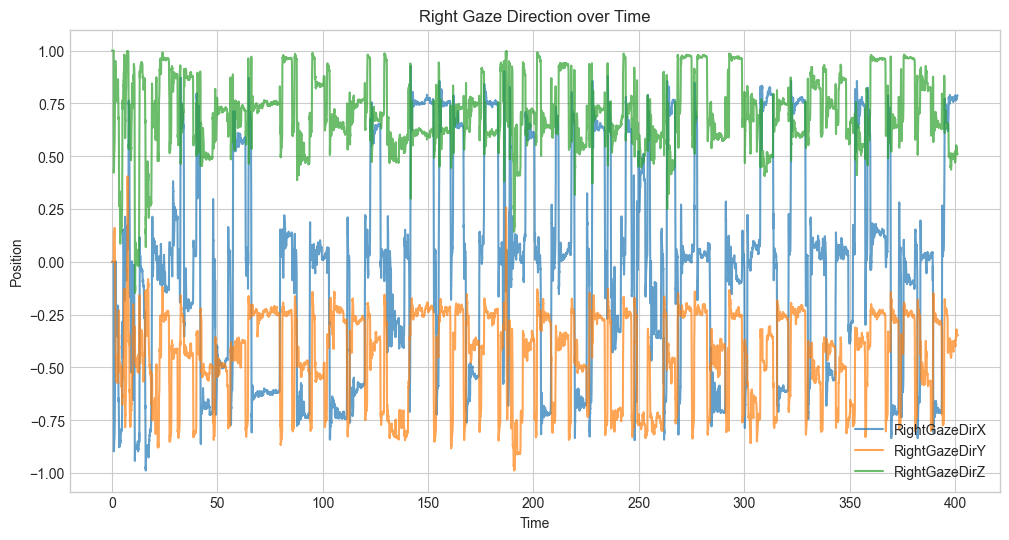

In [4]:
def plot_time_series(df, cols, title):
    plt.figure(figsize=(12, 6))
    for col in cols:
        plt.plot(df['Timestamp'], df[col], label=col, alpha=0.7)
    plt.xlabel('Time')
    plt.ylabel('Position')
    plt.title(title)
    plt.legend()
    plt.show()

plot_time_series(df, ['HandPosX', 'HandPosY', 'HandPosZ'], 'Hand Position over Time')
plot_time_series(df, ['RightGazeDirX', 'RightGazeDirY', 'RightGazeDirZ'], 'Right Gaze Direction over Time')